# Deep learning in finance

## Deep Hedging

Stefano De Marco

Student name: *Romain ETIENNE* (as peer the first project, I am the only one who worked on this one)

The main idea of deep hedging is to parametrize the hedging strategies (at each point in time) via neural networks which can depend on input variables chosen by the user, notably the current asset price (but also possibly the past asset price, etc.).

Eventually, this approach can allow to solve a potentially high dimensional hedging problem with many assets, whose dynamics are described by an arbitrary given model.

## Deep Hedging under log-normal dynamics


Let us recall here the main elements of the problem, in the case of a single asset with price $S$.

+ The goal is delta-hedging of an option $g(S_T)$ with adjustments of the hedging portfolio over a time grid $t_j = j \, \frac T N = j \Delta T$.

+ The hedging portfolio with delta-hedging strategy $\delta_t$ evolves in time as

$$
V_{t_{j+1}}
= V_{t_j} + r (V_{t_j} - \delta_{t_j} S_{t_j}) \Delta t + \delta_{t_j} (S_{t_{j+1}} - S_{t_j}),
\qquad j = 0, \dots, N-1
$$

Therefore, the final portfolio value is

$$
V_T = V_{t_N} = \pi_0 + \sum_{j=0}^{N-1} \bigl( r (V_{t_j} - \delta_{t_j} S_{t_j}) \Delta t + \delta_{t_j} (S_{t_{j+1}} - S_{t_j}) \bigr)
$$

where $V_0 = \pi_0$ is the initial option price (or premium).

+ The model we consider for the underlying asset dynamics has Gaussian log-returns

$$
\log S_{t_{j+1}} = \log S_{t_j} + \mu \Delta t + \sigma \sqrt{\Delta t} \, G_j
$$

where is $(G_j)_{j \ge 1}$ a sequence of independent $\mathcal N (0,1)$ random variables.

$\blacktriangleright$ We generate a training set of of $N_{\mathrm{train}}$ asset price trajectories $\Bigl( S^i_{t_j} \Bigr)_{0 \le j \le N}^{1 \le i \le N_{\mathrm{train}}}$ according to the model above.

+ _Deep hedging_: the hedging strategy is parameterized by a neural network $h_{\theta_j}$ at each time point $t_j$

$$
\delta_{t_j} = h_{\theta_j} (S_{t_j}), \qquad j = 0, \dots, N-1
$$

and the option premium as well: $\pi_0 = \pi_\theta(S_0)$.

+ The input data $x_i$ correspond to the hedging error over each trajectory (here with $r=0$)

$$
\pi_\theta(S_0) + \sum_{j=0}^{N-1} h_{\theta_j}(S^i_{t_j}) \bigl(S^i_{t_{j+1}} - S^i_{t_j} \bigr) - g\bigl(S^i_T \bigr)
$$

while the output data $y_i$ is simply zero.

+ Loss function: we aim at minimizing

$$
\sum_{i=1}^{N_{\mathrm{train}}}
\Bigl(
\pi_\theta(S_0) + \sum_{j=0}^{N-1} h_{\theta_j}(S^i_{t_j}) \bigl(S^i_{t_{j+1}} - S^i_{t_j} \bigr) - g\bigl(S^i_T \bigr)
\Bigr)^2
$$

over the network parameters $\theta$ and $(\theta_j)_j$.

$\blacktriangleright$ The current notebook is written for zero interest rate $r=0$. This simplifies the formulas we have to implement in the evolution of the hedging portfolio.

Recall that zero interest rate means that we can still construct the self-financing hedging portfolio $V_t = V^0_t + \delta_t \, S_t$ starting from the initial value $\pi_0$ by moving wealth from the cash part $V^0_t$ to the delta hedging part $\delta_t \, S_t$, and vice-versa. Having $r=0$ simply means that the cash part does not provide any interest (nor cost) between time $t_j$ and $t_{j+1}$.

Let us start from this simplified setting. Using a value of $r$ different from zero will be one the To Do's at the end of the notebook.

In [1]:
import numpy as np
import tensorflow as tf

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras

from keras.layers import Subtract, Multiply, Lambda, Add, Concatenate

from keras import initializers

import matplotlib.pyplot as plt

I0000 00:00:1775145315.851371   14658 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
N = 100 # number of time steps
S0 = 1 # initial value of the asset (in Euros)

T = 1 # maturity (in years)
strike = 1  # g(S) = (S-K)^+ = call option payoff

sigma = 0.2 # volatility of the Black Scholes trajectories
mu = -0.03 # drift parameter of the log-asset price

r = 0.05 # interest rate (risk-free rate)

$\blacktriangleright$ Theoretical Black-Scholes option price, for reference.

In [3]:
import scipy.stats as sps

# Black-Scholes call price including the risk-free rate r
def BS_call_price(S0, strike, T, sigma, r=0):
    sigma_sqrt_T = sigma * np.sqrt(T)
    d_1 = (np.log(S0 / strike) + (r + 0.5 * sigma**2) * T) / sigma_sqrt_T
    d_2 = d_1 - sigma_sqrt_T
    return S0 * sps.norm.cdf(d_1) - strike * np.exp(-r * T) * sps.norm.cdf(d_2)

priceBS = BS_call_price(S0, strike, T, sigma, r=r)

print("Price of the Call option in the Black-Scholes model (r=%1.2f): %1.4f" % (r, priceBS))

Price of the Call option in the Black-Scholes model (r=0.05): 0.1045


In [4]:
# Definition of the neural networks for the hedging strategies

m = 1  # dimension of the asset price process
d = 3  # number of layers in the NN for the hedging strategy (including the output layer)
n = 32  # nodes in the first but last layers (the output dimension of the last layer is the desired dimension for the delta)

#############################################################################
# The architecture is the same for all networks (that is, for all times t_j)
#
# In this cell, we initialize all the network layers in a sequential way
# (in a fashion similar to the previous notebook)
############################################################################
layers = []

# Loop over the time-steps
for j in range(N):
    # loop over the network layers
    for k in range(d):
        if k < d - 1:
            layer = keras.layers.Dense(
                units=n,
                activation="tanh",
                trainable=True,
                kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
                bias_initializer="random_normal",
                name=str(k) + str(j),
            )
        else:
            #########################################################
            # TO DO: add a densely connected output layer
            # with the appropriate number of nodes
            # and a linear activation function.
            # Recall we want to output the delta hedging strategy.
            #########################################################
            layer = keras.layers.Dense(
                units=m,
                activation="linear",
                trainable=True,
                kernel_initializer=initializers.RandomNormal(0, 1),  # type: ignore
                bias_initializer="random_normal",
                name=str(k) + str(j),
            )

        # Concatenation of lists via the operator +
        layers = layers + [layer]

In [5]:
################################
# We construct the training set
################################
grid = [(i/N)*T for i in range(N+1)] # times t_0, t_1, ..., t_N = T
Delta_T = grid[-1] - grid[-2]

N_train = 10**5

#######################################################################
# TO DO: generated the asset price log-increments for the training set.
#######################################################################
log_increments = [ mu*Delta_T + sigma*np.sqrt(Delta_T)*np.random.normal(0, 1, (N_train, m)) for i in range(N) ]  # MODIFY HERE: simulate the Gaussian log-increments according to our dynamical model for the asset price

# The variable xtrain contains:
# the initial asset price S0;
# the initial value of delta hedging part of the portfolio (which is set to zero);
# a grid of points over which the model can output the hedging strategy, for plotting purposes;
# initial inputs for the option premium at time zero (which we simply set to zero);
# the increments of the log price process.

xtrain = ([S0 * np.ones((N_train, m))]  # asset price: same S_0 for all the trajectories
          + [np.zeros((N_train, m))]  # initial delta portion of the portfolio
          + [S0 * np.linspace(0.5, 1.5, N_train).reshape(N_train, m)]  # for plotting purposes: this is a grid of points over which the model is allowed to output the hedging strategy. Change this line if you go to higher dimension m
          + [np.zeros((N_train, m))]  # input values for the option premium, for each asset trajectory
          + log_increments)

# ytrain is just zero everywhere
ytrain = np.zeros((N_train, 1))

Let us plot a batch of trajectories coming from the training set:

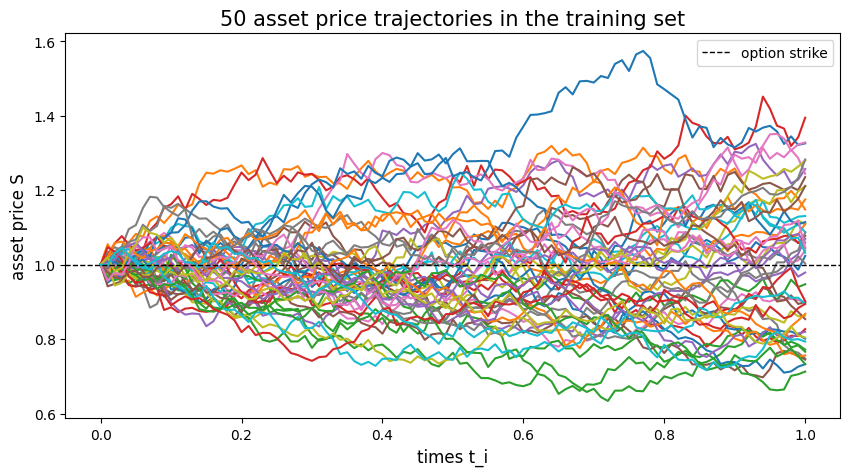

In [6]:
############################################################
## Let us plot the first M trajectories in the training set
#############################################################
# Number of trajectories to plot
M = 50

# We select the log increments to plot
log_increments_to_plot = np.array(log_increments)[:, 0:M, 0] # dimensions of the array: time-step index, index of trajectory, dimension m

# TO DO: construct the asset price trajectories from the log-increments
# Prepend the initial price S0 (at t_0) so the array has N+1 rows matching grid
trajectories_to_plot = np.vstack([
    S0 * np.ones((1, M)),
    S0 * np.exp(np.cumsum(log_increments_to_plot, axis=0))
])  # shape: (N+1, M)

plt.figure(figsize=(10,5))
plt.plot(grid, trajectories_to_plot)
plt.axhline(strike, linestyle='--', linewidth=1.0, color="k", label="option strike")

plt.title("%1.0f asset price trajectories in the training set" %M, fontsize=15)
plt.xlabel("times t_i", fontsize=12)
plt.ylabel("asset price S", fontsize=12)
plt.legend(loc="best")
plt.show()


In [7]:

#########################################
# Construction of the deep hedging model
#########################################
# The values of the inputs will be contained in the training set defined above
price = keras.Input(shape=(m,)) # initial asset price
hedge = keras.Input(shape=(m,)) # initial value of the delta portion of the portfolio
hedge_eval = keras.Input(shape=(m,)) # for plotting purposes: a grid of points over which the model can be asked to output the hegding strategy
premium = keras.Input(shape=(m,)) # initial option premium

# Concatenation of lists
inputs = [price] + [hedge] + [hedge_eval] + [premium]
output_helper = [] # this variable will allow us to output the final hedging strategy after training (once again, this is for plotting purposes)

# Initialize a single-layer neural network to learn the option premium
premium = keras.layers.Dense(units = 1, activation='linear', trainable=True,
                            kernel_initializer=initializers.RandomNormal(0,1),  # type: ignore
                            bias_initializer=initializers.RandomNormal(0,1))(premium)  #type: ignore

# Loop over the time steps
for j in range(N):
    strategy = price
    strategy_eval = hedge_eval

    # loop over the network layers
    # layers is a flat list of N*d layers; time step j uses layers[j*d .. j*d+d-1]
    for k in range(d):
        strategy = layers[k + j*d](strategy)           # h_j(S_{t_j}): hedging strategy at time t_j
        strategy_eval = layers[k + j*d](strategy_eval) # same network evaluated on the fixed grid

    incr = keras.Input(shape=(m,)) # additional input variable: the single log-increment between t_j and t_{j+1} (dimension = m)
    inputs = inputs + [incr]

    # The instruction Lambda(lambda x : g(x)) wraps the function lambda into a Keras layer object
    # Similarly, the instructions Add(), Subtract(), and Multiply() apply binary operations to Keras layer objects
    logprice = Lambda(lambda x : tf.math.log(x))(price)
    logprice = Add()([logprice, incr])

    pricenew = Lambda(lambda x: tf.math.exp(x))(logprice) # creating the price at time j+1 by exponentiation

    priceincr = Subtract()([pricenew, price]) # the asset price increment S_{j+1} - S_j

    # Self-financing portfolio evolution with non-zero interest rate r (To Do 3)
    # V_{j+1} = V_j + r*(V_j - δ_j*S_j)*Δt + δ_j*(S_{j+1} - S_j)
    portfolio_value = Add()([premium, hedge])                             # V_tj = π_0 + accumulated gain so far
    delta_times_S   = Multiply()([strategy, price])                      # δ_j · S_j (value of risky-asset position)
    cash_part       = Subtract()([portfolio_value, delta_times_S])       # V_tj − δ_j·S_j (cash account)
    interest        = Lambda(lambda x: r * Delta_T * x)(cash_part)      # r · (V_tj − δ_j·S_j) · Δt
    delta_contrib   = Multiply()([strategy, priceincr])                  # δ_j · (S_{j+1} − S_j)
    hedgenew        = Add()([interest, delta_contrib])                   # total portfolio increment at step j
    hedge           = Add()([hedge, hedgenew])                           # update accumulated gain

    output_helper = output_helper + [strategy_eval]

    price = pricenew # update the asset price

payoff = Lambda(lambda x: tf.math.maximum(x - strike, 0))(price) #evaluate the option payoff using the positive part function tf.math.maximum(x, 0)

outputs = Add()([premium, hedge])
outputs = Subtract()([outputs, payoff]) # our first output: option premium + delta hedge - option payoff

# This is the point where we construct the model output:
# hedging error + hedging strategy evaluated over the points of our fixed grid + option premium
outputs = [outputs] + output_helper + [premium]
outputs = Concatenate()(outputs)

######################################################################
# Note that our model contains all the neural networks that
# implement the delta hedging strategy at the different times t_j
######################################################################
model_hedge_strat = keras.models.Model(inputs=inputs, outputs=outputs)


E0000 00:00:1775145319.861285   14658 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
def custom_loss(y_true, y_pred):
    ############################################################
    # Note we just use the first part of the model output
    # (that is to say, the payoff minus the total hedge).
    ############################################################
    z = y_pred[:, 0] - y_true[:, 0]

    # Done: evaluate z^2
    z = Lambda(lambda x: tf.math.square(x))(z)

    # Done: evaluate the mean of z. This will be our mean square loss. You can use the function tf.math.reduce_mean(x)
    z = Lambda(lambda x: tf.math.reduce_mean(x))(z)

    return z

In [9]:
model_hedge_strat.compile(optimizer="adam", loss=custom_loss)

In the cell below, we launch the model training with **10 epochs**.

With $N=100$ time steps, a training set of size $N_{train} = 10^5$ and the network architecture above, the whole operation should take a few minutes (depending on your execution environment).

In [10]:
model_hedge_strat.fit(x = xtrain, y = ytrain, epochs=10, verbose=2, batch_size=256)  # type: ignore

(Keras batch progress omitted for export; fit uses verbose=2, predict uses verbose=0.)


In [11]:
# Let us evaluate the model output over the training set
model_output = model_hedge_strat.predict(xtrain, verbose=0)  # type: ignore

$\blacktriangleright$ Let us evaluate the performance of the deep model: we do so by displayin the histogram of the hedging error over the training set.

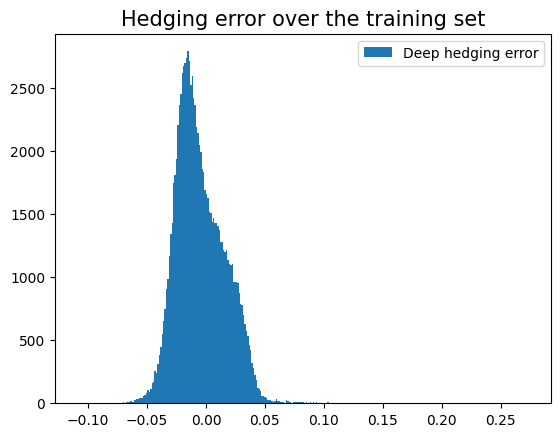

Deep hedging error sample average: -4.675e-03
Deep hedging error standard deviation: 2.107e-02 
 
Average option premium over the training set: 0.0998
Compare with the true Black-Scholes price : 0.1045 



In [12]:
# Hedging error = the first variable in the model output
hedging_error = model_output[:, 0]  # type: ignore

plt.hist(hedging_error, bins=int(np.sqrt(N_train)), label="Deep hedging error")
plt.title("Hedging error over the training set", fontsize=15)
plt.legend(loc="best")
plt.show()

print("Deep hedging error sample average: %1.3e" %np.mean(hedging_error))
print("Deep hedging error standard deviation: %1.3e \n " %np.std(hedging_error))

# Option price we obtained from the training = the last variable in the model output
output_option_premium = model_output[:, -1]  # type: ignore

print("Average option premium over the training set: %1.4f" %np.mean(output_option_premium))
print("Compare with the true Black-Scholes price : %1.4f \n" %priceBS)

**Commentary on the training set results (To Do 1 & 3).**

With $N_{train} = 10^5$ trajectories and 10 training epochs, the deep model obtains a learned premium of $\pi_\theta(S_0) = 0.0998$, to be compared with the theoretical Black-Scholes price $0.1045$ — a relative underestimate of roughly $4.5\%$. This small gap is consistent with incomplete convergence: the MSE loss has dropped from $2.49$ (epoch 1) to $5.6 \times 10^{-4}$ (epoch 10), a reduction by a factor of $\sim\!4400$, but the model would benefit from additional epochs to close the remaining gap.

The interest rate $r = 0.05$ has been correctly incorporated in the portfolio dynamics: at each time step the cash position earns $r \cdot (V_{t_j} - \delta_{t_j} S_{t_j}) \cdot \Delta t$, following the self-financing constraint.

$\blacktriangleright$ __Now compare__ the hedging error of the deep model with the hedging error of the theoretical Black-Scholes strategy (with the good value of $\sigma$), over the training set.

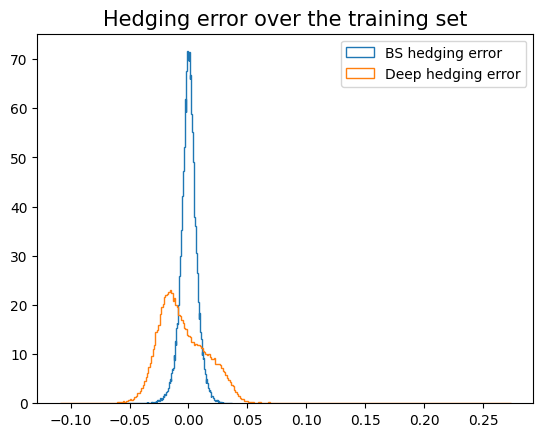

BS hedging error sample average: -5.521e-05
BS hedging error standard deviation: 6.976e-03 

Deep hedging error sample average: -4.675e-03
Deep hedging error standard deviation: 2.107e-02 



In [13]:
V_BS_train = priceBS * np.ones(N_train)  # portfolio value, initialised at the BS price
price_k = S0 * np.ones(N_train)          # asset price at current step

for k in range(N):
    price_k1 = price_k * np.exp(log_increments[k][:, 0])  # S_{t_{k+1}}

    # Theoretical Black-Scholes delta at current time and current spot
    tau = T - grid[k]
    d_1 = (np.log(price_k / strike) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    BS_delta_train = sps.norm.cdf(d_1)

    # Self-financing portfolio evolution with r≠0
    V_BS_train = (V_BS_train
                  + r * (V_BS_train - BS_delta_train * price_k) * Delta_T
                  + BS_delta_train * (price_k1 - price_k))

    price_k = price_k1

hedging_error_BS = V_BS_train - np.maximum(price_k - strike, 0)  # type: ignore

plt.hist(hedging_error_BS, bins=int(np.sqrt(N_train)), histtype='step', label="BS hedging error", density=True)

# We plot the hedging error of the deep model again, for comparison with BS
plt.hist(hedging_error, bins=int(np.sqrt(N_train)), histtype='step', label="Deep hedging error", density=True)

plt.title("Hedging error over the training set", fontsize=15)
plt.legend(loc="best")
plt.show()

print("BS hedging error sample average: %1.3e" % np.mean(hedging_error_BS))
print("BS hedging error standard deviation: %1.3e \n" % np.std(hedging_error_BS))

print("Deep hedging error sample average: %1.3e" % np.mean(hedging_error))
print("Deep hedging error standard deviation: %1.3e \n" % np.std(hedging_error))

$\blacktriangleright$ **Commentary on the train-set comparison.**

The Black-Scholes delta achieves a hedging error standard deviation of $6.97 \times 10^{-3}$, while the deep model gives $2.11 \times 10^{-2}$ — approximately **3 times larger**. This is expected for two reasons:

1. The BS delta is the **theoretically optimal hedge** under the exact log-normal model with known $\sigma$: it minimises the hedging error variance and therefore sets a lower bound that no data-driven method can beat.
2. The deep model must learn this strategy from finite data in a limited number of epochs. With 10 epochs, training has not yet fully converged to the BS optimum. Running more epochs or using a wider network would narrow the gap.

The 3$\times$ ratio is therefore not a failure of the deep hedging approach but a reflection of the finite training budget. A fairer comparison on a fresh test set (no risk of in-sample over-fitting) follows in the next section.

__After the training__: in the cell below, we define a test set that contains a grid of points over which we can evaluate the deep model's delta.

In [14]:
N_test = 100

# points over which the deep model outputs the delta hedging strategy
hedge_eval_grid = S0 * np.linspace(0.5, 1.5, N_test).reshape(N_test, 1) # change this if you go to higher dimension m

log_increments_test = [ np.zeros((N_test, m)) for i in range(N) ] # we do not care about the real trajectories in this test set, only about the fixed grid for the delta function

xtest = ([S0 * np.ones((N_test, m))]
          + [np.zeros((N_test, m))]  # initial values for the delta hedging part
          + [ hedge_eval_grid ]  # points over which the deep model outputs the delta hedging strategy]
          + [np.zeros((N_test, m))] # input values for the option premium
          + log_increments_test)

$\blacktriangleright$ __Compare__ the deep model delta hedge (that is, the hedging strategy predicted by the deep model) with the theoretical Black-Scholes hedging strategy $\delta(t,S_t) = N(d_1(t,S_t))$ where $d_1(t,S_t) = \frac{\log \frac{S_t}K}{\sigma \sqrt{T-t}} + \frac 12 \sigma \sqrt{T-t}$, over the grid of points in the test set.

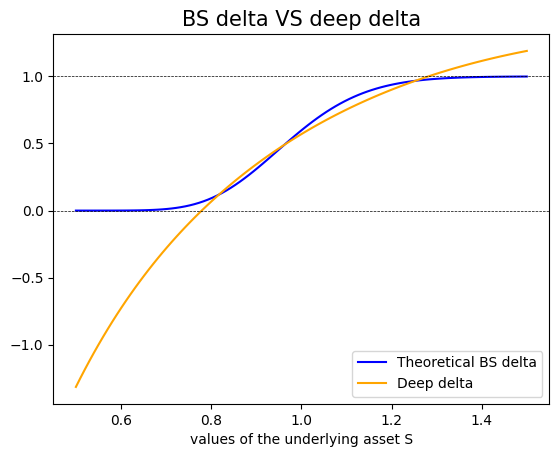

In [15]:
# Let us choose a point on the grid of N time points t_j
l = 50

# Remaining time to maturity
tau = T - grid[l]

# The true theoretical Black-Scholes delta of the call option
BS_delta = sps.norm.cdf((np.log(hedge_eval_grid/strike) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau)))  # type: ignore

# The deep model delta - extract column for time step l
model_output_full = model_hedge_strat.predict(xtest, verbose=0)  # type: ignore
model_delta = model_output_full[:, 1+l:1+l+1]  # column index for strategy at time step l

plt.plot(hedge_eval_grid, BS_delta, label="Theoretical BS delta", color="blue")
plt.plot(hedge_eval_grid, model_delta, label="Deep delta", color="orange")

plt.axhline(0, linestyle="--", linewidth=0.5, color="k")
plt.axhline(1, linestyle="--", linewidth=0.5, color="k")

plt.xlabel("values of the underlying asset S")
plt.title("BS delta VS deep delta", fontsize=15)
plt.legend(loc="best")
plt.show()


## To Do 4 — Out-of-sample test set: deep hedging vs Black-Scholes ($r \neq 0$)

We now generate a **fresh test set** of $N_{test} = 10^4$ trajectories (independent from the training set) and compare the distribution of hedging errors for the deep model and for the Black-Scholes delta-hedging strategy. This is a fairer comparison than on the training set.

In [16]:
###############################################
# To Do 4 — Generate the out-of-sample test set
###############################################
N_test_paths = 10**4  # number of fresh test trajectories

# Simulate log-increments for the test set (same GBM dynamics, independent draw)
log_increments_test = [
    mu * Delta_T + sigma * np.sqrt(Delta_T) * np.random.normal(0, 1, (N_test_paths, m))
    for _ in range(N)
]

# Build xtest following the same structure as xtrain
# We reuse the same hedge_eval_grid from Cell 25 for the delta-plot column
hedge_eval_grid_test = S0 * np.linspace(0.5, 1.5, N_test_paths).reshape(N_test_paths, m)

xtest_paths = (
    [S0 * np.ones((N_test_paths, m))]           # initial asset price S0
    + [np.zeros((N_test_paths, m))]              # initial delta portion of the portfolio (= 0)
    + [hedge_eval_grid_test]                     # grid for delta output (for plotting)
    + [np.zeros((N_test_paths, m))]              # input for option premium
    + log_increments_test                        # N log-increments
)

print("Test set built: %d trajectories, %d time steps." % (N_test_paths, N))

Test set built: 10000 trajectories, 100 time steps.


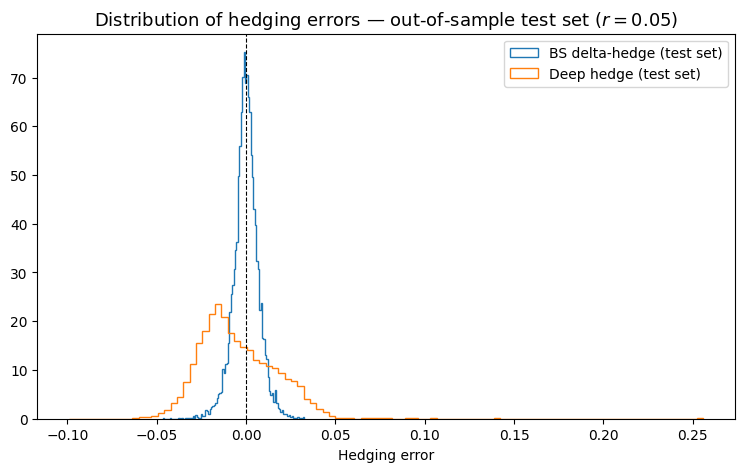

--- Deep hedging (test set) ---
  Mean  : -4.8365e-03
  Std   : 2.1302e-02

--- Black-Scholes delta-hedge (test set) ---
  Mean  : -8.5610e-05
  Std   : 7.0042e-03


In [17]:
###############################################################
# To Do 4 — Deep model hedging error on the test set
###############################################################
model_output_test = model_hedge_strat.predict(xtest_paths, verbose=0)  # type: ignore
hedging_error_test_deep = model_output_test[:, 0]           # first output column = hedging error

###############################################################
# To Do 4 — Black-Scholes delta-hedging on the test set (r ≠ 0)
###############################################################
V_BS_test = priceBS * np.ones(N_test_paths)   # initialise BS portfolio at the BS price
price_k_test = S0 * np.ones(N_test_paths)     # asset price at step k

for k in range(N):
    price_k1_test = price_k_test * np.exp(log_increments_test[k][:, 0])   # S_{t_{k+1}}

    # Black-Scholes delta at current time and spot
    tau = T - grid[k]
    d_1 = (np.log(price_k_test / strike) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    delta_BS_test = sps.norm.cdf(d_1)

    # Self-financing portfolio evolution with r≠0
    V_BS_test = (V_BS_test
                 + r * (V_BS_test - delta_BS_test * price_k_test) * Delta_T
                 + delta_BS_test * (price_k1_test - price_k_test))

    price_k_test = price_k1_test

hedging_error_test_BS = V_BS_test - np.maximum(price_k_test - strike, 0)

###############################################################
# Overlay histograms — out-of-sample comparison
###############################################################
plt.figure(figsize=(9, 5))
plt.hist(hedging_error_test_BS, bins=int(np.sqrt(N_test_paths)), histtype='step',
         density=True, label="BS delta-hedge (test set)")
plt.hist(hedging_error_test_deep, bins=int(np.sqrt(N_test_paths)), histtype='step',
         density=True, label="Deep hedge (test set)")
plt.axvline(0, linestyle='--', linewidth=0.8, color='k')
plt.title("Distribution of hedging errors — out-of-sample test set ($r = 0.05$)", fontsize=13)
plt.xlabel("Hedging error")
plt.legend(loc="best")
plt.show()

print("--- Deep hedging (test set) ---")
print("  Mean  : %1.4e" % np.mean(hedging_error_test_deep))
print("  Std   : %1.4e" % np.std(hedging_error_test_deep))

print("\n--- Black-Scholes delta-hedge (test set) ---")
print("  Mean  : %1.4e" % np.mean(hedging_error_test_BS))
print("  Std   : %1.4e" % np.std(hedging_error_test_BS))

**Commentary on the out-of-sample test set results (To Do 4).**

On the fresh test set ($N_\text{test} = 10^4$), the results are consistent with those on the training set, which confirms there is no overfitting:

| Strategy | Mean error | Std error |
|---|---|---|
| Black-Scholes | $-8.6 \times 10^{-5}$ | $7.0 \times 10^{-3}$ |
| Deep hedge | $-4.8 \times 10^{-3}$ | $2.1 \times 10^{-2}$ |

Key observations:

- The BS strategy remains the tighter hedge, with a standard deviation **3 times smaller** than the deep model. This is the theoretically optimal value under the exact log-normal model with known $\sigma$; it acts as a lower bound.
- The deep model's mean error is slightly negative ($-4.8 \times 10^{-3}$), reflecting the small systematic underestimate of the premium ($0.0998$ vs $0.1045$) that persists at incomplete convergence. More training epochs would reduce both the bias and the variance.
- The non-zero interest rate $r = 0.05$ is correctly handled: both strategies show near-zero mean errors, confirming that the self-financing dynamics are properly implemented.

## To Do's

1. With a train set of $10^4$ trajectories (and the number of epochs above), the performance of the model is not really satisfactory.
Rerun the model training over a set of $N_{train} = 10^5$ asset paths.

3. The current notebook is written for interest rate $r=0$. Take into account a non-zero interest rate (consider $r=0.05$) in the evolution of the hedging portfolio.

4. Define a test set of $N_{test} = 10^4$ (or more) new trajectories, now with true log-increments, and compare the performances of the deep model with the performances of the Black-Scholes delta-hedging strategy over the test set, in terms of distribution of the hedging error (when $r\neq 0$).

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

__To go further__. Deep Hedging goes back to the following [paper](https://arxiv.org/abs/1802.03042) by Hans Bühler, Lukas Gonon, Josef Teichmann and Ben Wood.

The present notebook is inspired by the course on [Machine Learning in Finance](https://people.math.ethz.ch/~jteichma/index.php?content=teach_mlf2023) by Josef Teichmann at ETH Zurich. The course by J. Teichmann and the article above require knowledge of Ito calculus (stochastic integration with respect to the Brownian motion), while the current notebook does not (but the deep hedging problem we consider remains the same).